<a href="https://colab.research.google.com/github/pattichis/MLSP2026/blob/main/Medical_Video_Diffusion_Tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Medical Video Generation with Diffusion: A Fast Tutorial

We train a small **video diffusion model** from scratch that generates **echocardiography-style videos** of a beating heart, and we control how strongly the heart pumps by conditioning on the **ejection fraction (EF)**: the fraction of blood the left ventricle ejects with each beat (normal ≈ 55–70%; below 40% indicates heart failure).

**How diffusion works**

1. **Forward process (fixed):** gradually add Gaussian noise to a real video until it is pure noise.
2. **Model (learned):** a 3D U-Net learns to undo the noise, given the noisy video, the noise level, and the EF.
3. **Generation:** start from pure noise and repeatedly remove the predicted noise. After 50 steps, a new video emerges.

**Data.** Real echo datasets (e.g., EchoNet-Dynamic, CAMUS) require a data-use agreement, so this tutorial generates **synthetic** ultrasound-like clips: a beating, elliptical left ventricle (dark blood pool, bright heart wall) inside an ultrasound fan, with speckle noise. Each clip is one heartbeat, 16 frames of 32 × 32 pixels, and we know its exact EF. The same code runs on real data once the clips are loaded as tensors.

**Runtime.** **Runtime → Change runtime type → T4 GPU**. Total time: about 5–10 minutes. The model is small and briefly trained, so results are blurry but clearly show the idea.

| Section | Content |
|---|---|
| 1 | Synthetic echo videos with known EF |
| 2 | The forward (noising) process |
| 3 | A small 3D U-Net, conditioned on noise level and EF |
| 4 | Fast training |
| 5 | Generate new videos for a requested EF |
| 6 | Check: does the generated EF match the requested EF? |

## 1. Synthetic echocardiography videos

The generator below draws random hearts: random size, shape, tilt, position, starting phase in the cardiac cycle, and **EF between 20% and 70%**. EF is defined here from the 2D cavity area: EF = 1 − (smallest area / largest area). You don't need to read the generator in detail.

In [ ]:
import copy, math, time, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0)
T, S = 16, 32                                    # frames per clip, frame size

yy, xx = torch.meshgrid(torch.arange(S, device=device).float(), torch.arange(S, device=device).float(), indexing="ij")
fan = ((xx - S / 2).atan2(yy + 2).abs() < 0.75) & ((xx - S / 2) ** 2 + (yy + 2) ** 2 < (S + 1) ** 2)   # ultrasound sector

def make_echo(B, ef=None):
    """Return B synthetic echo clips (B, 1, T, S, S) scaled to [-1, 1], and their EF (B,)."""
    r = lambda lo, hi: lo + (hi - lo) * torch.rand(B, 1, 1, 1, device=device)
    ef = r(0.2, 0.7) if ef is None else ef.view(B, 1, 1, 1).to(device)
    t = torch.arange(T, device=device).view(1, T, 1, 1) / T
    r_max, aspect, tilt = r(6, 8.5), r(1.3, 1.6), r(-0.35, 0.35)
    cx, cy = r(14, 18), r(14, 18)
    r_min = r_max * (1 - ef).sqrt()                                   # area ratio = 1 - EF
    rad = r_min + (r_max - r_min) * (0.5 + 0.5 * torch.cos(2 * math.pi * (t + r(0, 1))))   # (B, T, 1, 1)
    u = (xx - cx) * tilt.cos() + (yy - cy) * tilt.sin()
    v = -(xx - cx) * tilt.sin() + (yy - cy) * tilt.cos()
    dist = ((u / rad) ** 2 + (v / (aspect * rad)) ** 2).sqrt() * rad   # ~ distance from center, in pixels
    cavity = torch.sigmoid(2 * (rad - dist))
    wall = torch.sigmoid(2 * (rad + 3 - dist)) - cavity                # 3-pixel-thick heart wall
    img = 0.35 * (1 - cavity - wall) + 0.05 * cavity + 0.9 * wall
    img = img * (1 + 0.1 * torch.randn_like(img)).clamp(min=0)        # mild speckle noise
    img = img * fan
    return (img.clamp(0, 1) * 2 - 1)[:, None], ef.view(B)

def animate(videos, titles, fps=8):
    """Show several videos (N, 1, T, S, S) in [-1, 1] side by side as an animation."""
    n = len(videos)
    fig, ax = plt.subplots(1, n, figsize=(2 * n, 2.3))
    ax = [ax] if n == 1 else ax
    ims = []
    for a, v, title in zip(ax, videos, titles):
        ims.append(a.imshow(v[0, 0].cpu(), cmap="gray", vmin=-1, vmax=1)); a.set_title(title, fontsize=9); a.axis("off")
    def update(f):
        for im, v in zip(ims, videos): im.set_data(v[0, f].cpu())
        return ims
    anim = animation.FuncAnimation(fig, update, frames=T, interval=1000 / fps)
    plt.close(fig)
    return HTML(anim.to_jshtml())

real, ef = make_echo(6, torch.tensor([0.2, 0.3, 0.4, 0.5, 0.6, 0.7]))
animate(real, [f"real, EF {e:.0%}" for e in ef])

Press ▶ to play. Low EF (left) barely contracts; high EF (right) squeezes strongly.

## 2. The forward process: adding noise

We use the standard DDPM setup with 1,000 noise levels and a cosine schedule. At level *t*, a clean video *x₀* becomes

  *xₜ* = √ᾱₜ · *x₀* + √(1 − ᾱₜ) · *ε*,  with *ε* ~ N(0, I)

where ᾱₜ falls from 1 (clean) to about 0 (pure noise).

The network is trained to predict *v* = √ᾱₜ · *ε* − √(1 − ᾱₜ) · *x₀*, a mix of the noise and the clean video (**v-prediction**, Salimans & Ho, 2022). From *v* and *xₜ* we can recover both *x₀* and *ε*. Compared with predicting only the noise *ε*, v-prediction is stable at the highest noise levels and gives cleaner results after short training.

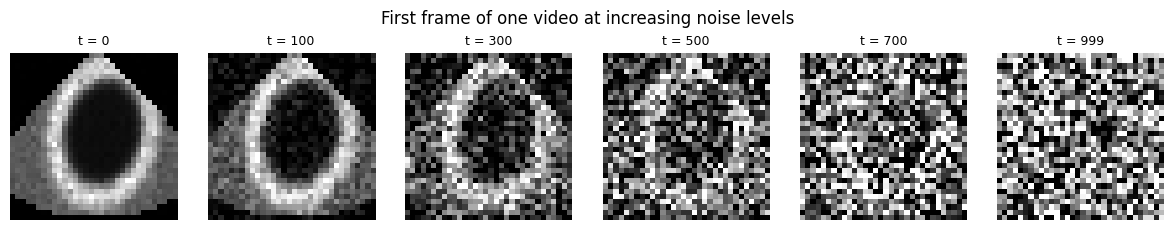

In [ ]:
N_STEPS = 1000
s = torch.arange(N_STEPS + 1, device=device) / N_STEPS
alpha_bar = (torch.cos((s + 0.008) / 1.008 * math.pi / 2) ** 2)
alpha_bar = (alpha_bar[1:] / alpha_bar[0]).clamp(1e-5, 1)          # cosine schedule, ᾱ_t for t = 0..999

def add_noise(x0, t, noise):
    ab = alpha_bar[t].view(-1, 1, 1, 1, 1)
    return ab.sqrt() * x0 + (1 - ab).sqrt() * noise

x0 = real[3:4]
levels = [0, 100, 300, 500, 700, 999]
fig, ax = plt.subplots(1, len(levels), figsize=(12, 2.3))
for a, t in zip(ax, levels):
    xt = add_noise(x0, torch.tensor([t], device=device), torch.randn_like(x0))
    a.imshow(xt[0, 0, 0].cpu(), cmap="gray", vmin=-1, vmax=1); a.set_title(f"t = {t}", fontsize=9); a.axis("off")
fig.suptitle("First frame of one video at increasing noise levels"); plt.tight_layout(); plt.show()

## 3. The model: a small 3D U-Net

The denoiser is a **3D U-Net**: 3D convolutions over (time, height, width), downsampling 16 × 32 × 32 → 8 × 16 × 16 → 4 × 8 × 8 and back up, with skip connections.

It receives two conditioning signals, both turned into one embedding vector that is added inside every residual block:
- **the noise level *t*** (sinusoidal embedding, as in Transformers), so it knows how much noise to remove;
- **the EF** (a small MLP), so it knows *what kind* of heart to generate.

In [ ]:
def timestep_embedding(t, dim):
    half = dim // 2
    freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / half)
    args = t.float()[:, None] * freqs[None]
    return torch.cat([args.sin(), args.cos()], dim=1)

class ResBlock(nn.Module):
    def __init__(self, c_in, c_out, emb_dim):
        super().__init__()
        self.norm1, self.conv1 = nn.GroupNorm(8, c_in), nn.Conv3d(c_in, c_out, 3, padding=1)
        self.emb = nn.Linear(emb_dim, c_out)
        self.norm2, self.conv2 = nn.GroupNorm(8, c_out), nn.Conv3d(c_out, c_out, 3, padding=1)
        self.skip = nn.Conv3d(c_in, c_out, 1) if c_in != c_out else nn.Identity()
    def forward(self, x, e):
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.emb(e)[:, :, None, None, None]          # inject noise level + EF
        h = self.conv2(F.silu(self.norm2(h)))
        return h + self.skip(x)

class UNet3D(nn.Module):
    def __init__(self, c=16, emb_dim=128):
        super().__init__()
        self.emb_dim = emb_dim
        self.t_mlp = nn.Sequential(nn.Linear(emb_dim, emb_dim), nn.SiLU(), nn.Linear(emb_dim, emb_dim))
        self.ef_mlp = nn.Sequential(nn.Linear(1, emb_dim), nn.SiLU(), nn.Linear(emb_dim, emb_dim))
        self.inc = nn.Conv3d(1, c, 3, padding=1)
        self.d1, self.down1 = ResBlock(c, c, emb_dim), nn.Conv3d(c, c, 3, stride=2, padding=1)
        self.d2, self.down2 = ResBlock(c, 2 * c, emb_dim), nn.Conv3d(2 * c, 2 * c, 3, stride=2, padding=1)
        self.mid1, self.mid2 = ResBlock(2 * c, 4 * c, emb_dim), ResBlock(4 * c, 4 * c, emb_dim)
        self.u2 = ResBlock(4 * c + 2 * c, 2 * c, emb_dim)
        self.u1 = ResBlock(2 * c + c, c, emb_dim)
        self.out = nn.Sequential(nn.GroupNorm(8, c), nn.SiLU(), nn.Conv3d(c, 1, 3, padding=1))
    def forward(self, x, t, ef):
        e = self.t_mlp(timestep_embedding(t, self.emb_dim)) + self.ef_mlp(ef[:, None])
        up = lambda h: F.interpolate(h, scale_factor=2, mode="nearest")
        h1 = self.d1(self.inc(x), e)                           # 16 x 32 x 32
        h2 = self.d2(self.down1(h1), e)                        #  8 x 16 x 16
        h = self.mid2(self.mid1(self.down2(h2), e), e)         #  4 x  8 x  8
        h = self.u2(torch.cat([up(h), h2], 1), e)
        h = self.u1(torch.cat([up(h), h1], 1), e)
        return self.out(h)                                     # predicted v, same shape as x

model = UNet3D().to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters()) / 1e6:.1f} M")
print("Output shape:", tuple(model(real, torch.zeros(6, dtype=torch.long, device=device), ef).shape))

Parameters: 0.7 M
Output shape: (6, 1, 16, 32, 32)


## 4. Fast training

Each step: draw fresh synthetic clips, pick a random noise level for each, add noise, and train the U-Net to predict *v* (mean squared error). Mixed precision on the GPU and data generated on the GPU keep this fast.

We also keep an **EMA** (exponential moving average) copy of the weights, updated after every step. Generating with the EMA weights averages out the noisy late updates and gives much cleaner videos, especially after short training. Almost all diffusion models do this.

The model will **not** fully converge in this short run; more steps give sharper videos.

step   250   loss 0.1786      19 s
step   500   loss 0.0944      38 s
step   750   loss 0.0823      58 s
step  1000   loss 0.0776      78 s
step  1250   loss 0.0747      98 s
step  1500   loss 0.0747     119 s


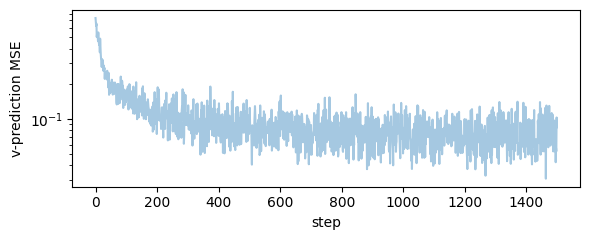

In [ ]:
STEPS, BATCH, LR, EMA_DECAY = 1500, 32, 5e-4, 0.995
use_amp = device == "cuda"
opt = torch.optim.AdamW(model.parameters(), lr=LR)
ema = copy.deepcopy(model).eval().requires_grad_(False)
scaler = torch.amp.GradScaler(enabled=use_amp)

losses, t0 = [], time.time()
model.train()
for step in range(1, STEPS + 1):
    x0, ef = make_echo(BATCH)
    t = torch.randint(0, N_STEPS, (BATCH,), device=device)
    noise = torch.randn_like(x0)
    ab = alpha_bar[t].view(-1, 1, 1, 1, 1)
    v_target = ab.sqrt() * noise - (1 - ab).sqrt() * x0
    with torch.autocast(device_type=device, dtype=torch.float16, enabled=use_amp):
        loss = F.mse_loss(model(add_noise(x0, t, noise), t, ef).float(), v_target)
    opt.zero_grad(set_to_none=True)
    scaler.scale(loss).backward()
    scaler.step(opt); scaler.update()
    with torch.no_grad():
        for p_ema, p in zip(ema.parameters(), model.parameters()):
            p_ema.lerp_(p, 1 - EMA_DECAY)                       # EMA update
    losses.append(loss.item())
    if step % 250 == 0:
        print(f"step {step:5d}   loss {sum(losses[-250:]) / 250:.4f}   {time.time() - t0:5.0f} s")

plt.figure(figsize=(6, 2.5)); plt.plot(losses, alpha=0.4); plt.yscale("log")
plt.xlabel("step"); plt.ylabel("v-prediction MSE"); plt.tight_layout(); plt.show()

## 5. Generate new heart videos

We sample with **DDIM** (Song et al., 2021): instead of the 1,000 small steps used in training, it jumps through **50** noise levels deterministically, which is 20× faster. At each step the model predicts *v*, we estimate the clean video and the noise, and we move to the next, lower noise level.

We ask for six hearts with EF from 20% (severely reduced) to 70% (normal).

In [ ]:
@torch.no_grad()
def generate(ef, steps=50, net=None):
    net = net or ema                                               # use the EMA weights
    ef = ef.to(device)
    x = torch.randn(len(ef), 1, T, S, S, device=device)            # start from pure noise
    ts = torch.linspace(N_STEPS - 1, 0, steps, device=device).long()
    for i, t in enumerate(ts):
        ab = alpha_bar[t]
        ab_next = alpha_bar[ts[i + 1]] if i + 1 < steps else torch.tensor(1.0, device=device)
        with torch.autocast(device_type=device, dtype=torch.float16, enabled=use_amp):
            v = net(x, t.repeat(len(x)), ef).float()
        x0 = (ab.sqrt() * x - (1 - ab).sqrt() * v).clamp(-1, 1)      # estimate of the clean video
        eps = (x - ab.sqrt() * x0) / (1 - ab).sqrt()
        x = ab_next.sqrt() * x0 + (1 - ab_next).sqrt() * eps            # DDIM step to the next level
    return x

t0 = time.time()
requested = torch.tensor([0.2, 0.3, 0.4, 0.5, 0.6, 0.7])
fake = generate(requested)
print(f"Generated {len(fake)} videos in {time.time() - t0:.1f} s")
animate(fake, [f"generated, EF {e:.0%}" for e in requested])

Generated 6 videos in 0.4 s


Press ▶. Each video should show a beating ventricle, contracting weakly on the left and strongly on the right. The model never copies a training clip: every video is drawn from new random noise.

## 6. Check: does the generated EF match the requested EF?

A generated medical video is only useful if it has the properties we asked for. We measure EF directly from the pixels: segment the dark blood pool in each frame (smooth, then threshold), and compute EF = 1 − (smallest area / largest area). First we check this measurement on real clips, where the true EF is known; then we apply it to 64 generated clips.

Measurement check on real clips: mean |measured - true| EF = 0.034
Generated clips: mean |measured - requested| EF = 0.093, correlation = 0.76


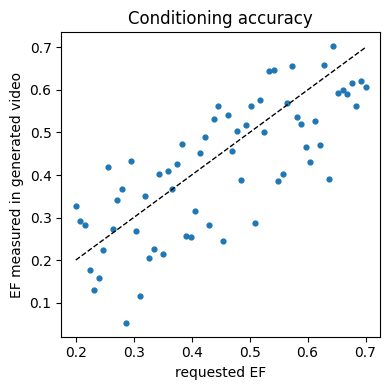

In [ ]:
def measure_ef(videos):
    x = (videos[:, 0] + 1) / 2                                        # (N, T, S, S) in [0, 1]
    x = F.avg_pool2d(x.reshape(-1, 1, S, S), 3, stride=1, padding=1).reshape(x.shape)
    area = ((x < 0.2) & fan).sum((2, 3)).float()                     # dark blood-pool pixels inside the fan
    return 1 - area.min(1).values / area.max(1).values.clamp(min=1)

ref_video, ref_ef = make_echo(256)
print(f"Measurement check on real clips: mean |measured - true| EF = {(measure_ef(ref_video) - ref_ef).abs().mean():.3f}")

req = torch.linspace(0.2, 0.7, 64)
got = measure_ef(generate(req)).cpu()
print(f"Generated clips: mean |measured - requested| EF = {(got - req).abs().mean():.3f}, "
      f"correlation = {torch.corrcoef(torch.stack([req, got]))[0, 1]:.2f}")

plt.figure(figsize=(4, 4))
plt.scatter(req, got, s=12); plt.plot([0.2, 0.7], [0.2, 0.7], "k--", lw=1)
plt.xlabel("requested EF"); plt.ylabel("EF measured in generated video")
plt.title("Conditioning accuracy"); plt.tight_layout(); plt.show()

**What to notice.** In our test run (1,500 steps), the EF measured in 64 generated videos had a **correlation of 0.77** with the requested EF, and a mean error of **0.07**. For comparison, the measurement itself has an error of about 0.03 on real clips. Most points follow the dashed line: the model learned to make the heart pump weakly or strongly on request. The points far from the line, mostly at low requested EF, are failures you would not notice by eye. Training longer, using a larger model (`UNet3D(c=32)`), or adding classifier-free guidance all tighten this relationship.

This check is the key lesson of the tutorial: before synthetic medical videos are used for anything, verify that they have the clinical properties you asked for.

## Key ideas

| Concept | Meaning |
|---|---|
| Forward process | Mix the video with Gaussian noise; the amount is set by the noise level *t* |
| Denoiser | A 3D U-Net predicts *v* (a mix of noise and clean video) from the noisy video, *t*, and the condition |
| Conditioning | Extra inputs (here EF) steer *what* is generated |
| DDIM sampling | 50 deterministic denoising steps instead of 1,000 |
| Validation | Measure the requested property in the generated data; don't trust appearance alone |

## Next steps

- **Real data:** EchoNet-Dynamic (about 10,000 echo videos with EF labels, Stanford; requires a data-use agreement) and CAMUS. Load clips as tensors of shape (N, 1, T, H, W) scaled to [−1, 1] and replace `make_echo`.
- **Bigger videos:** use *latent* video diffusion (compress frames with an autoencoder first) and attention across time; see work on echocardiogram synthesis such as Reynaud et al., MICCAI 2023.
- **Stronger conditioning:** classifier-free guidance (randomly drop the condition during training, then amplify it at sampling time).
- **Responsible use:** synthetic medical data must be validated before use in research or training clinical models (realism, correct labels, no memorization of patients), and clearly labeled as synthetic.